<a href="https://colab.research.google.com/github/darthnylus/frame-chime-clone/blob/main/01_customer_churn_decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction using Decision Trees (CART)

**Portfolio Project** – End-to-end machine learning pipeline that predicts whether a customer will churn from a video-streaming / telecom-style subscription service.

Inspired by real-world churn modeling use cases (similar in scope to ProjectPro’s Decision Tree Churn project).

---

### Business Objective

A subscription-based company wants to identify customers who are likely to cancel their plan so that the retention team can take proactive action (offers, support calls, contract upgrades, etc.).

**Goal**: Build an interpretable Decision Tree classifier that:
- Predicts churn (Yes / No)
- Surfaces the most important drivers of churn
- Handles class imbalance with SMOTE
- Can be easily explained to non-technical stakeholders

### Demonstrate
- Data inspection & cleaning
- Feature encoding
- Handling class imbalance (SMOTE)
- Building a CART Decision Tree with scikit-learn
- Model evaluation (Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix)
- Feature importance analysis
- Visualizing the decision tree
- Saving the model for later use

### Tech Stack
`Python` · `pandas` · `NumPy` · `scikit-learn` · `imbalanced-learn` · `matplotlib` · `seaborn`


# Customer Churn Prediction using Decision Trees (CART)

**Portfolio Project** – End-to-end machine learning pipeline that predicts whether a customer will churn from a video-streaming / telecom-style subscription service.

Inspired by real-world churn modeling use cases (similar in scope to ProjectPro’s Decision Tree Churn project).

---

### Business Objective

A subscription-based company wants to identify customers who are likely to cancel their plan so that the retention team can take proactive action (offers, support calls, contract upgrades, etc.).

**Goal**: Build an interpretable Decision Tree classifier that:
- Predicts churn (Yes / No)
- Surfaces the most important drivers of churn
- Handles class imbalance with SMOTE
- Can be easily explained to non-technical stakeholders

### What you will learn / demonstrate
- Data inspection & cleaning
- Feature encoding
- Handling class imbalance (SMOTE)
- Building a CART Decision Tree with scikit-learn
- Model evaluation (Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix)
- Feature importance analysis
- Visualizing the decision tree
- Saving the model for later use

### Tech Stack
`Python` · `pandas` · `NumPy` · `scikit-learn` · `imbalanced-learn` · `matplotlib` · `seaborn`


## 1. Import Required Libraries

We start by importing all the libraries we need for data handling, modeling, evaluation, and visualization.


In [ ]:
# Suppress minor warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Core data science libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)
from sklearn.preprocessing import LabelEncoder

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Model persistence
import pickle
from pathlib import Path

# Set a consistent style for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
print("Libraries imported successfully.")


Libraries imported successfully.


In [1]:
# Suppress minor warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Core data science libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)
from sklearn.preprocessing import LabelEncoder

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Model persistence
import pickle
from pathlib import Path

# Set a consistent style for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Dataset

The dataset contains information about customers of a subscription service.  
Each row represents one customer and the target variable `Churn` indicates whether the customer left (`Yes`) or stayed (`No`).

**Path**: `../data/customer_churn.csv`


In [ ]:
# Define project paths (works both in notebook and script context)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "data" / "customer_churn.csv"
FIGURES = ROOT / "figures"
MODELS = ROOT / "models"

FIGURES.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

# Load the data
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


Dataset shape: 2500 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST-00001,Male,0,Yes,No,11,Yes,No,DSL,No,...,Yes,No,No,Yes,One year,Yes,Electronic check,54.22,670.42,No
1,CUST-00002,Female,0,Yes,No,9,Yes,No,DSL,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,34.33,313.83,Yes
2,CUST-00003,Female,0,No,Yes,4,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Electronic check,18.00,64.64,No
3,CUST-00004,Female,1,Yes,Yes,22,Yes,Yes,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,72.54,1725.30,Yes
4,CUST-00005,Male,0,No,No,15,Yes,Yes,Fiber optic,No,...,No,Yes,No,No,One year,Yes,Electronic check,73.69,1045.44,No


## 3. Exploratory Data Analysis (EDA)

Before modeling we should understand:
- Target distribution (is the data imbalanced?)
- Missing values
- Basic statistics of numeric features
- Cardinality of categorical features


Churn value counts:
Churn
No     1415
Yes    1085
Name: count, dtype: int64

Churn rate:
Churn
No     0.566
Yes    0.434
Name: proportion, dtype: float64


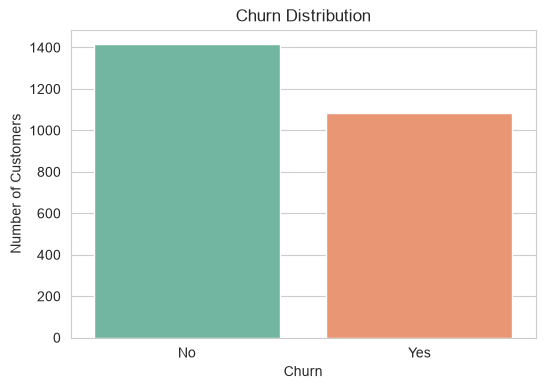

In [ ]:
# Target distribution
print("Churn value counts:")
print(df["Churn"].value_counts())
print("\nChurn rate:")
print(df["Churn"].value_counts(normalize=True).round(3))

# Visualize target balance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn", palette="Set2")
plt.title("Churn Distribution")
plt.ylabel("Number of Customers")
plt.show()


In [ ]:
# Missing values check
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values: 0


Numeric features summary:


,tenure,MonthlyCharges,TotalCharges
count,2500.00,2500.00,2500.00
mean,22.80,62.18,1417.31
std,20.38,27.40,1539.65
min,1.00,18.00,15.33
25%,6.00,37.63,325.23
50%,16.00,63.20,893.88
75%,34.00,83.40,1960.20
max,72.00,120.00,9490.97


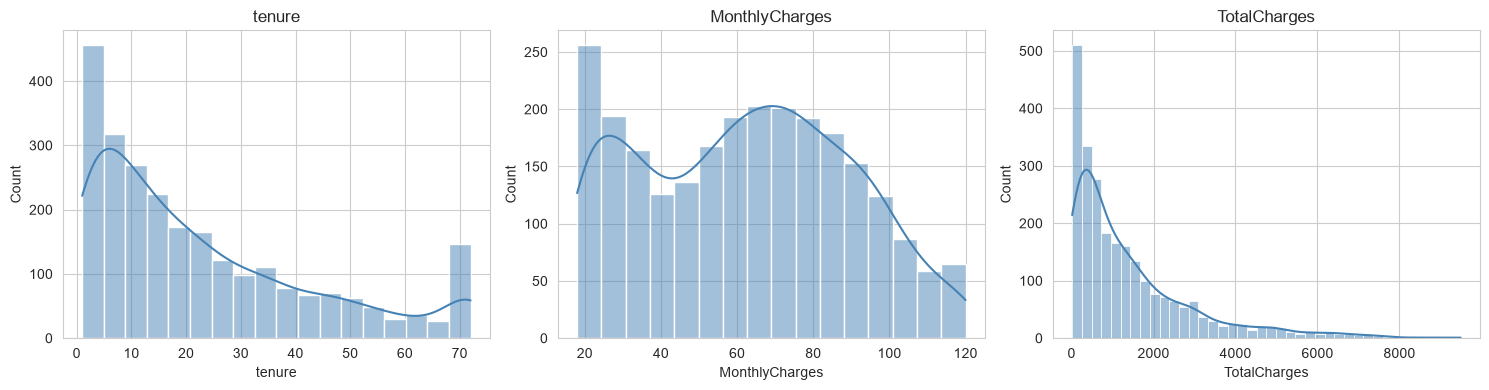

In [ ]:
# Numeric features summary
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
print("Numeric features summary:")
display(df[numeric_cols].describe().round(2))

# Distribution of key numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [ ]:
# Quick look at categorical features
cat_cols = df.select_dtypes(include="object").columns.tolist()
# Remove target and ID if present
cat_cols = [c for c in cat_cols if c not in ["Churn", "customerID"]]

print("Categorical columns and their unique values:")
for col in cat_cols:
    print(f"  {col:20s} → {df[col].nunique()} unique values")


Categorical columns and their unique values:
  gender               → 2 unique values
  Partner              → 2 unique values
  Dependents           → 2 unique values
  PhoneService         → 2 unique values
  MultipleLines        → 3 unique values
  InternetService      → 3 unique values
  OnlineSecurity       → 3 unique values
  OnlineBackup         → 3 unique values
  DeviceProtection     → 3 unique values
  TechSupport          → 3 unique values
  StreamingTV          → 3 unique values
  StreamingMovies      → 3 unique values
  Contract             → 3 unique values
  PaperlessBilling     → 2 unique values
  PaymentMethod        → 4 unique values


## 4. Data Preprocessing

Steps:
1. Drop the unique identifier (`customerID`) – it has no predictive power.
2. Convert the target `Churn` from string (`Yes`/`No`) to binary (1/0).
3. Label-encode all remaining categorical features so that the Decision Tree can use them.

> **Note**: Decision Trees can work with categorical features if we encode them.  
> Label Encoding is sufficient here because trees split on thresholds and do not assume ordinality the way linear models do.


In [ ]:
# Make a clean copy
data = df.copy()

# 1. Drop customerID
data = data.drop(columns=["customerID"])

# 2. Convert target to binary
data["Churn"] = (data["Churn"] == "Yes").astype(int)
print("Target converted to 0/1")
print(data["Churn"].value_counts())


Target converted to 0/1
Churn
0    1415
1    1085
Name: count, dtype: int64


In [ ]:
# 3. Label-encode all object columns
cat_cols = data.select_dtypes(include="object").columns.tolist()
le_dict = {}   # store encoders in case we need inverse_transform later

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    le_dict[col] = le

print(f"Encoded columns: {cat_cols}")
data.head()


Encoded columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,11,1,0,0,0,0,2,0,0,2,1,1,2,54.22,670.42,0
1,0,0,1,0,9,1,0,0,2,2,2,2,2,2,0,1,2,34.33,313.83,1
2,0,0,0,1,4,1,0,2,1,1,1,1,1,1,1,1,2,18.00,64.64,0
3,0,1,1,1,22,1,2,0,0,0,0,0,2,2,0,1,2,72.54,1725.30,1
4,1,0,0,0,15,1,2,1,0,2,0,2,0,0,1,1,2,73.69,1045.44,0


In [ ]:
# Separate features and target
X = data.drop(columns=["Churn"])
y = data["Churn"]

feature_names = X.columns.tolist()
print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {len(feature_names)}")


Feature matrix shape: (2500, 19)
Number of features: 19


## 5. Train / Test Split

We use a **stratified** split so that both the training and test sets keep the same churn rate as the original data.  
This is especially important when the target is imbalanced.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y          # preserves class distribution
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTrain churn rate: {y_train.mean():.1%}")
print(f"Test  churn rate: {y_test.mean():.1%}")


Training set : 1875 samples
Test set     : 625 samples

Train churn rate: 43.4%
Test  churn rate: 43.4%


## 6. Handling Class Imbalance with SMOTE

Decision Trees (and most classifiers) can be biased toward the majority class when the data is imbalanced.

**SMOTE** (Synthetic Minority Over-sampling Technique) creates synthetic examples of the minority class by interpolating between existing minority samples.

We apply SMOTE **only on the training set** to avoid data leakage.


In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_res).value_counts())
print(f"New training size: {X_train_res.shape[0]}")


Before SMOTE:
Churn
0    1061
1     814
Name: count, dtype: int64

After SMOTE:
Churn
0    1061
1    1061
Name: count, dtype: int64
New training size: 2122


## 7. Build the Decision Tree (CART)

We use scikit-learn’s `DecisionTreeClassifier`, which implements the **CART** algorithm (Classification and Regression Trees).

Key hyperparameters we set for regularization (to reduce overfitting):
- `max_depth=6` – limits how deep the tree can grow
- `min_samples_split=40` – a node must have at least 40 samples before it can be split
- `min_samples_leaf=20` – each leaf must contain at least 20 samples
- `criterion="gini"` – impurity measure used by CART

These values are a reasonable starting point; they can later be tuned with GridSearchCV.


In [ ]:
clf = DecisionTreeClassifier(
    criterion="gini",       # CART default
    max_depth=6,
    min_samples_split=40,
    min_samples_leaf=20,
    random_state=42,
)

# Train on the SMOTE-resampled data
clf.fit(X_train_res, y_train_res)
print("Decision Tree trained successfully!")
print(f"Tree depth: {clf.get_depth()}")
print(f"Number of leaves: {clf.get_n_leaves()}")


Decision Tree trained successfully!
Tree depth: 6
Number of leaves: 43


## 8. Model Evaluation

We evaluate the model on the **original (non-SMOTE) test set**.  
This gives a realistic estimate of how the model will perform on new, unseen customers.


In [ ]:
# Predictions
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]   # probability of churn

# Core metrics
print("=" * 45)
print("MODEL PERFORMANCE ON TEST SET")
print("=" * 45)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")


MODEL PERFORMANCE ON TEST SET
Accuracy : 0.6160
Precision: 0.5564
Recall   : 0.5646
F1-Score : 0.5604
ROC-AUC  : 0.6903


In [ ]:
# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))



Classification Report:
              precision    recall  f1-score   support

    No Churn       0.66      0.66      0.66       354
       Churn       0.56      0.56      0.56       271

    accuracy                           0.62       625
   macro avg       0.61      0.61      0.61       625
weighted avg       0.62      0.62      0.62       625



### Confusion Matrix

The confusion matrix shows:
- **True Negatives** (top-left): correctly predicted non-churners
- **False Positives** (top-right): non-churners incorrectly flagged as churn
- **False Negatives** (bottom-left): actual churners that we missed
- **True Positives** (bottom-right): correctly predicted churners


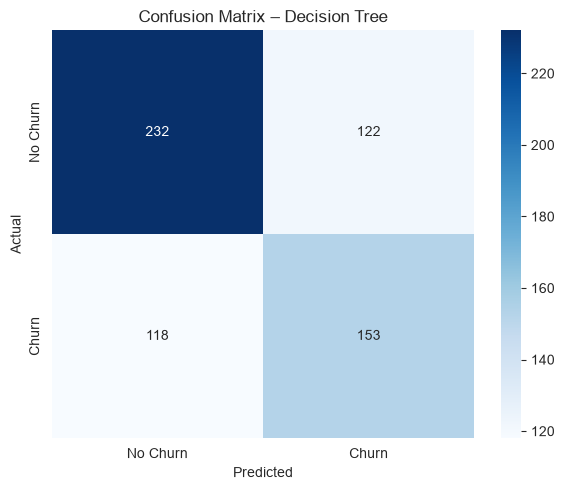

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
)
plt.title("Confusion Matrix – Decision Tree")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(FIGURES / "confusion_matrix.png", dpi=150)
plt.show()


### ROC Curve & AUC

The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate at different probability thresholds.  
AUC close to 1.0 indicates a strong classifier; 0.5 is random guessing.


<Figure size 700x500 with 0 Axes>

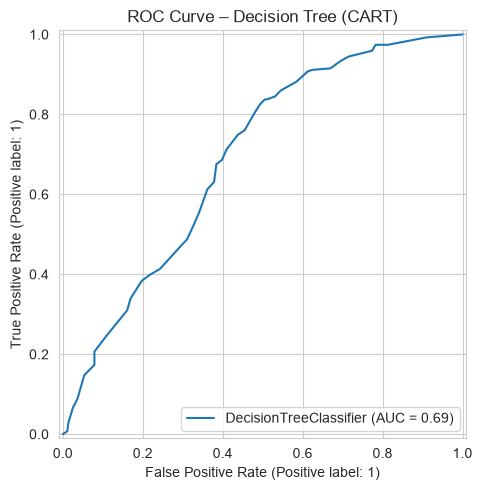

In [ ]:
plt.figure(figsize=(7, 5))
RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.title("ROC Curve – Decision Tree (CART)")
plt.tight_layout()
plt.savefig(FIGURES / "roc_curve.png", dpi=150)
plt.show()


## 9. Feature Importance

Decision Trees provide a built-in measure of feature importance based on how much each feature reduces impurity (Gini) across all splits.

This is extremely useful for business stakeholders – it tells them **which factors most strongly drive churn**.


In [ ]:
importances = pd.Series(clf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

print("Feature Importance (Gini):")
print(importances.round(4))


Feature Importance (Gini):
Contract            0.4355
tenure              0.2093
MonthlyCharges      0.1478
TotalCharges        0.0855
Partner             0.0344
TechSupport         0.0232
PaymentMethod       0.0191
Dependents          0.0120
gender              0.0095
OnlineSecurity      0.0086
InternetService     0.0065
PaperlessBilling    0.0045
DeviceProtection    0.0041
SeniorCitizen       0.0000
PhoneService        0.0000
OnlineBackup        0.0000
MultipleLines       0.0000
StreamingMovies     0.0000
StreamingTV         0.0000
dtype: float64


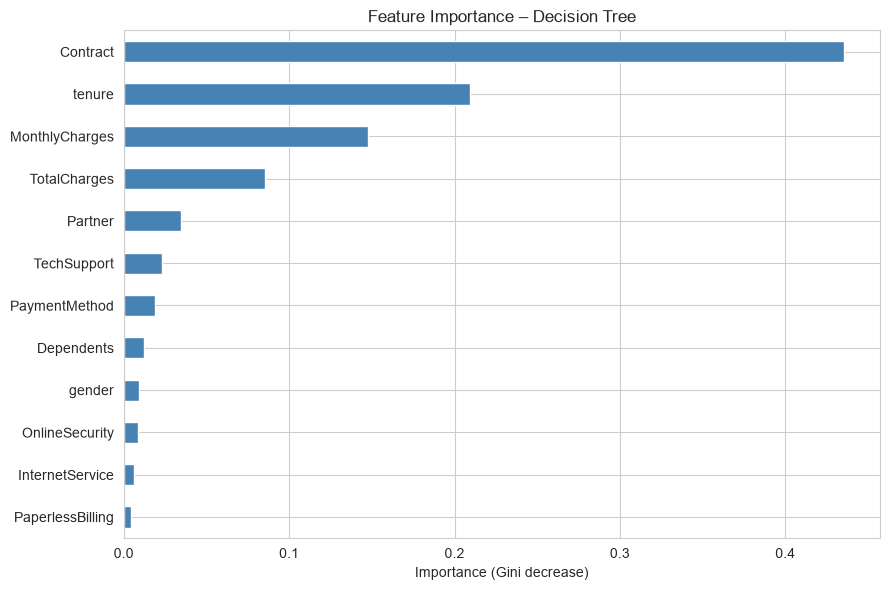

In [ ]:
plt.figure(figsize=(9, 6))
importances.head(12).plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Feature Importance – Decision Tree")
plt.xlabel("Importance (Gini decrease)")
plt.tight_layout()
plt.savefig(FIGURES / "feature_importance.png", dpi=150)
plt.show()


**Interpretation (typical results)**:
- **Contract** type is usually the strongest predictor (month-to-month customers churn far more).
- **tenure** (how long the customer has been with the company) is another major driver.
- **MonthlyCharges** and **TotalCharges** also play important roles.


## 10. Visualize the Decision Tree

One of the biggest advantages of Decision Trees is interpretability.  
We can plot the actual decision rules the model learned.


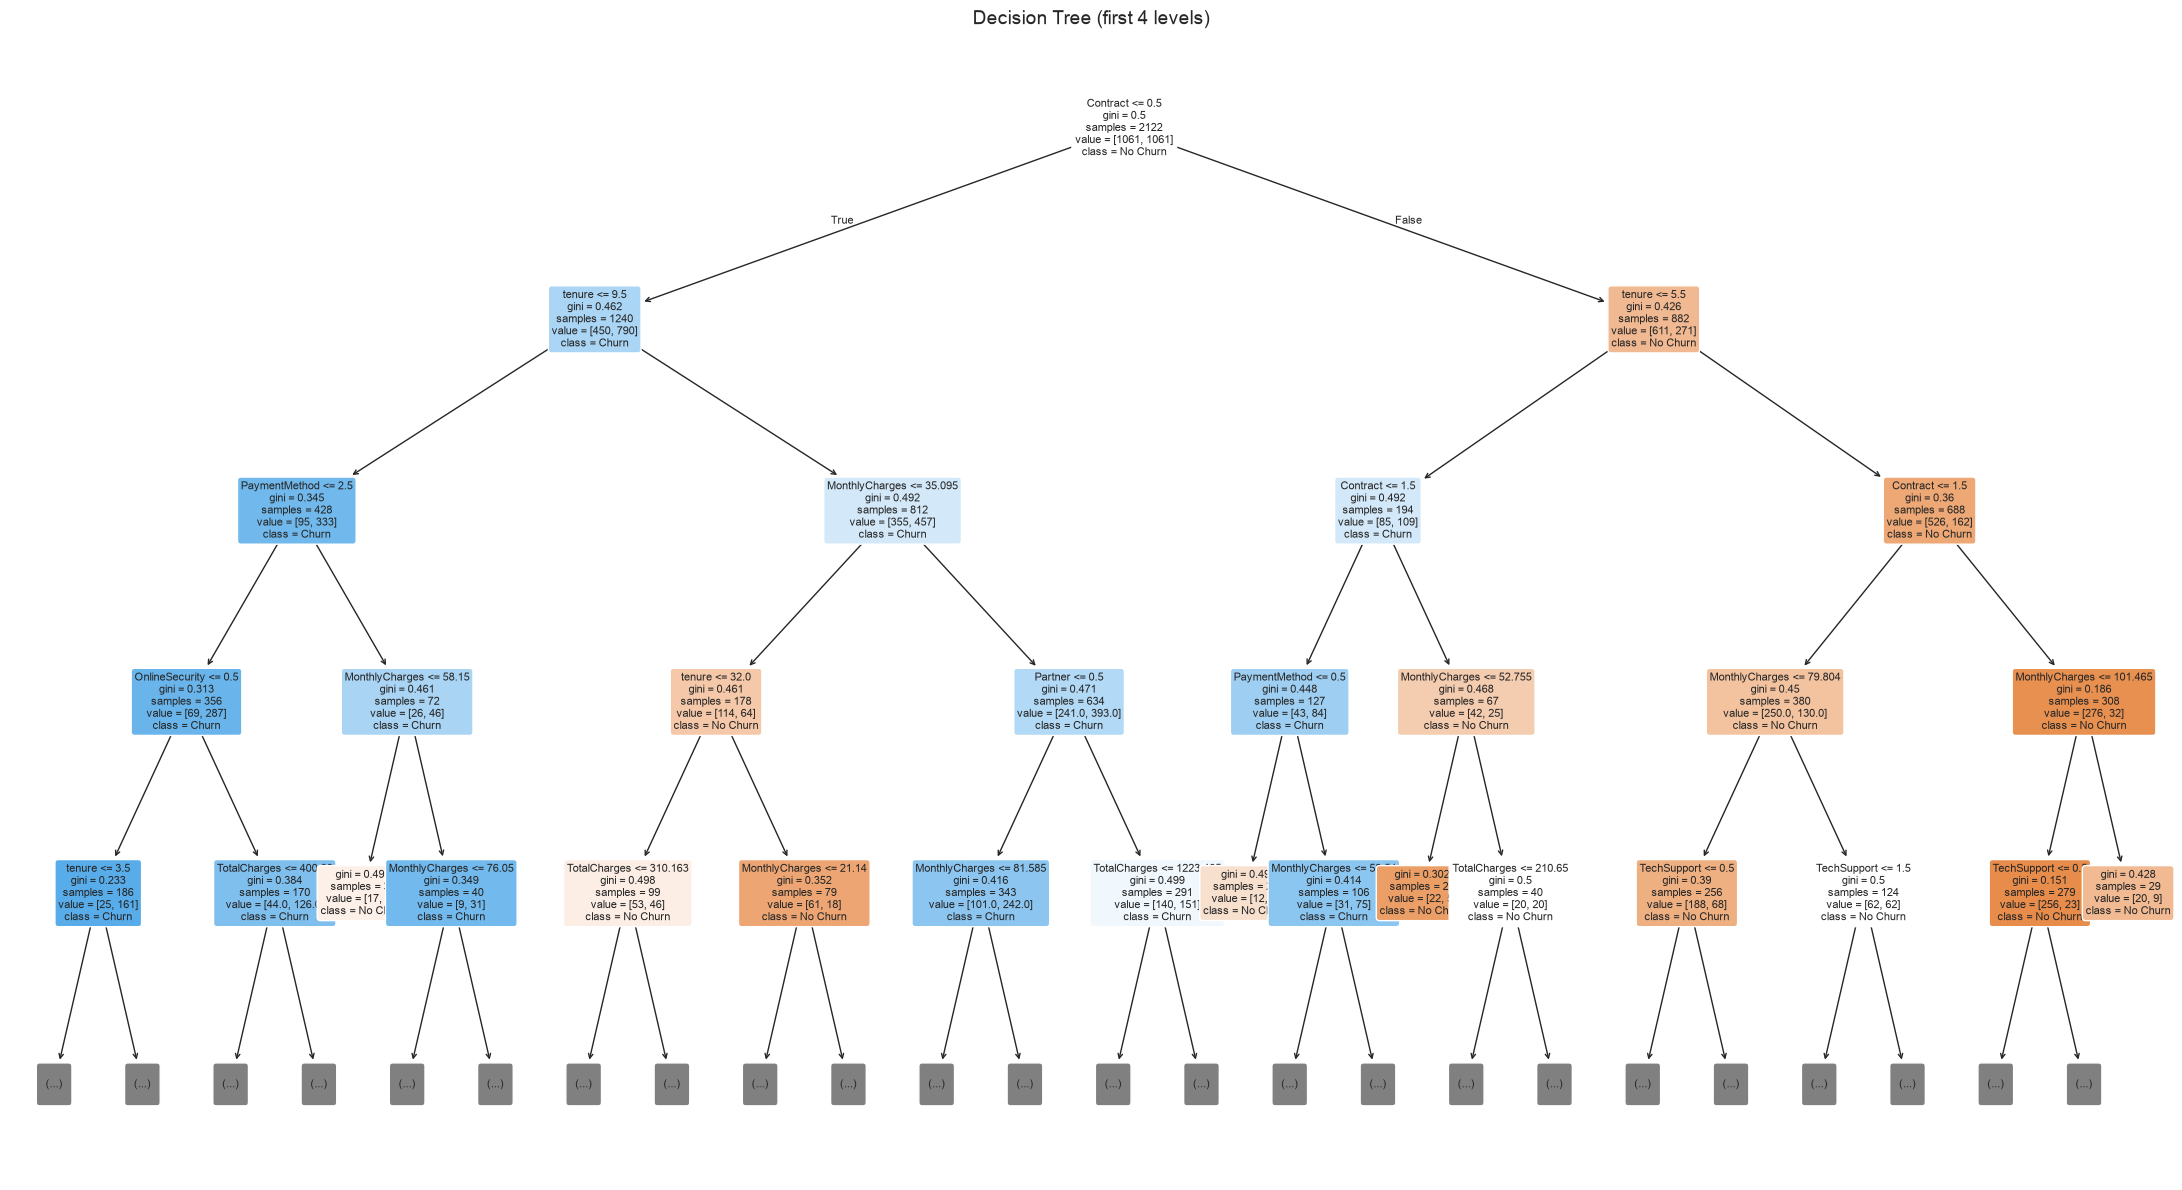

In [ ]:
plt.figure(figsize=(22, 12))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4,          # show only first 4 levels for readability
)
plt.title("Decision Tree (first 4 levels)", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES / "decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Text representation of the rules (useful for documentation)
tree_rules = export_text(clf, feature_names=feature_names, max_depth=4)
print(tree_rules)

# Also save to file
with open(FIGURES / "tree_rules.txt", "w") as f:
    f.write(tree_rules)


|--- Contract <= 0.50
|   |--- tenure <= 9.50
|   |   |--- PaymentMethod <= 2.50
|   |   |   |--- OnlineSecurity <= 0.50
|   |   |   |   |--- tenure <= 3.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- tenure >  3.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- OnlineSecurity >  0.50
|   |   |   |   |--- TotalCharges <= 400.66
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- TotalCharges >  400.66
|   |   |   |   |   |--- class: 1
|   |   |--- PaymentMethod >  2.50
|   |   |   |--- MonthlyCharges <= 58.15
|   |   |   |   |--- class: 0
|   |   |   |--- MonthlyCharges >  58.15
|   |   |   |   |--- MonthlyCharges <= 76.05
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- MonthlyCharges >  76.05
|   |   |   |   |   |--- class: 1
|   |--- tenure >  9.50
|   |   |--- MonthlyCharges <= 35.10
|   |   |   |--- tenure <= 32.00
|   |   |   |   |--- TotalCharges <= 310.16
|   |   |   |   |   |--- class: 1
|   |   |

## 11. Cross-Validation (optional sanity check)

We run a quick 5-fold cross-validation on the SMOTE-resampled training data to get a more robust estimate of performance.


In [ ]:
cv_scores = cross_val_score(
    clf, X_train_res, y_train_res,
    cv=5,
    scoring="f1"
)
print(f"5-Fold CV F1-score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


5-Fold CV F1-score: 0.6777 ± 0.0421


## 12. Save the Model

We save both the trained Decision Tree and the label encoders so that we can later load them and make predictions on new customers without re-fitting.


In [ ]:
artifact = {
    "model": clf,
    "label_encoders": le_dict,
    "feature_names": feature_names,
}

model_path = MODELS / "churn_decision_tree.pkl"
with open(model_path, "wb") as f:
    pickle.dump(artifact, f)

print(f"Model saved to: {model_path}")


Model saved to: /Users/gerard/Downloads/customer-churn-decision-tree/models/churn_decision_tree.pkl


## 13. Summary & Next Steps

### What we built
- A complete, reproducible churn prediction pipeline using a Decision Tree (CART)
- Proper handling of class imbalance with SMOTE
- Full evaluation suite + visualizations
- Feature importance insights that are actionable for the business
- A serialized model ready for inference

### Possible improvements (great talking points in interviews)
1. **Hyperparameter tuning** with `GridSearchCV` or `RandomizedSearchCV`
2. Compare against other models (Logistic Regression, Random Forest, XGBoost)
3. Use **SHAP** values for even richer interpretability
4. Cost-sensitive learning (different cost for false negatives vs false positives)
5. Deploy as a simple Streamlit or FastAPI application
6. Replace the synthetic data with the public [Telco Customer Churn dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

---

**Thank you for following along!**  
Feel free to fork this notebook, experiment with different depths, or add more models.
